#  **The IQR (Interquartile Range) Method for Outlier Detection**

The **IQR Method** (also known as the Tukey Fences method) is a non-parametric outlier detection technique. Unlike the Z-score method, it does not assume your data follows a normal distribution. Instead, it relies on **percentiles** and **quartiles**, making it the absolute best choice for identifying anomalies in skewed or heavily asymmetrical data.

---

## 1. Core Mathematical Concept & Quartiles

The IQR method divides your sorted dataset into four equal quarters using three specific landmarks called **Quartiles**:

*   **Q1 (25th Percentile / Lower Quartile):** The value below which 25% of the data falls.
*   **Q2 (50th Percentile / Median):** The exact middle value of the dataset.
*   **Q3 (75th Percentile / Upper Quartile):** The value below which 75% of the data falls.

### Calculating the Interquartile Range (IQR)

The IQR represents the distance between the upper and lower quartiles. It captures the middle **50%** of your dataset, completely isolating the core body of data from extreme tail behaviors:

$$\text{IQR} = \text{Q3} - \text{Q1}$$

---

## 2. Defining the Outlier Thresholds (Tukey's Fences)

To mathematically draw boundaries around your data, John Tukey established a standard rule using a multiplier of **1.5** times the IQR space. This sets up an upper and lower "fence":

- $\text{Lower Fence (Floor)} = \text{Q1} - (1.5 \times \text{IQR})$
- $\text{Upper Fence (Ceiling)} = \text{Q3} + (1.5 \times \text{IQR})$

### How Outliers are Flagged

*   Any data point that falls **below the Lower Fence** (< Lower Fence) is classified as a **negative outlier**.
*   Any data point that climbs **above the Upper Fence** (> Upper Fence) is classified as a **positive outlier**.

>Note: In rare scenarios requiring extreme outlier filtering, a multiplier of 3.0 is substituted for 1.5 to isolate "far out" anomalies.

---

## 3. Visual Representation: The Box Plot

The IQR method maps perfectly onto a standard data science **Box Plot** (Box-and-Whisker plot):

*   **The Box:** Extends from Q1 to Q3, visually showcasing the IQR span.
*   **The Middle Line:** Represents Q2 (the Median).
*   **The Whiskers:** Extend outward from the box to the lowest and highest non-outlier data points within the computed fences.
*   **Individual Dots:** Any points plotted as loose dots outside the whiskers are your flagged outliers.

---

## 4. Prerequisites for Use (When to Apply)

*   **Skewed or Asymmetric Distributions:** This technique is purpose-built for features like `Income`, `Real_Estate_Prices`, or `Web_Traffic_Clicks` that naturally have a long tail on one side.

*   **Data Containing Heavy Outliers:** Because percentiles ignore absolute extreme values, the thresholds remain rock-solid even if massive data typos or corrupt rows are present.

---

## 5. Advantages (Benefits)

*   **Highly Robust Against Extreme Outliers:** Unlike the mean and standard deviation (which wrap around outliers), quartiles are completely immune to individual massive values. A typo of `\$90,000,000` will not shift Q1 or Q3 significantly.

*   **No Distribution Assumptions:** It makes zero assumptions about whether your data looks like a bell curve, making it safe and universally applicable across diverse numerical columns.

---

## 6. Disadvantages and Risks (Why to Avoid)

*   **Loss of Context in Perfect Normal Distributions:** If applied to a perfectly symmetric, normal distribution, the 1.5 × IQR rule naturally marks roughly **0.7%** of your valid data points as outliers by default. If your sample size is tiny, you risk discarding perfectly healthy data.

---

## 7. Python / Pandas Implementation

Here is how to calculate thresholds, identify, and extract outliers using the IQR method in Python:

```python
import numpy as np
import pandas as pd

# 1. Create a heavily skewed dataset (e.g., Household Income) with an outlier
data = {'Income':} # 450k is an outlier
df = pd.DataFrame(data)

# 2. Calculate Quartiles (Q1, Q3) and the Interquartile Range
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

# 3. Calculate Threshold Fences
lower_fence = Q1 - (1.5 * IQR)
upper_fence = Q3 + (1.5 * IQR)

# 4. Filter and isolate the outliers
outliers = df[(df['Income'] < lower_fence) | (df['Income'] > upper_fence)]

print(f"IQR: {IQR}")
print(f"Lower Fence: {lower_fence} | Upper Fence: {upper_fence}")
print(f"Identified {len(outliers)} outlier row(s):")
print(outliers)
```


## 1. Outlier Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import Data set
df = pd.read_csv("../data/placement.csv")
df.sample(5)

,cgpa,placement_exam_marks,placed
760,7.13,48.0,1
481,7.33,32.0,0
824,7.48,27.0,1
1,7.46,38.0,1
935,8.12,37.0,1


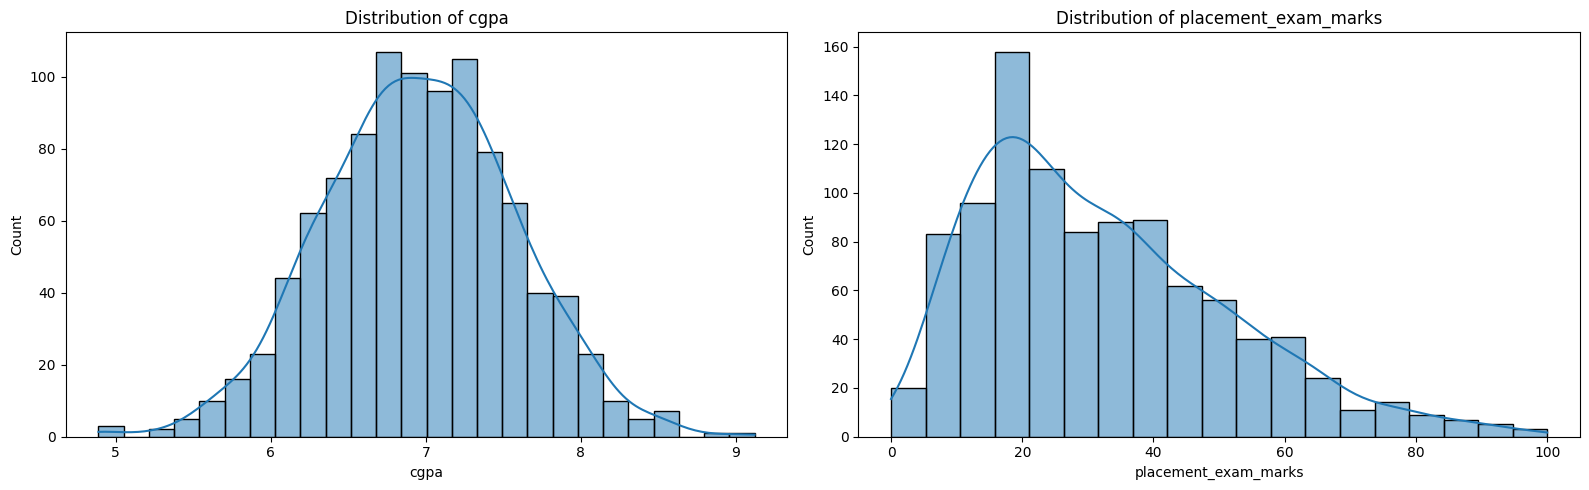

In [3]:
# Distribution plot of the features

def plot_dist(df, feat1, feat2):
    
    fig, axes = plt.subplots(1,2, figsize=(16,5))
    
    # For Feature 1:
    sns.histplot(df[feat1], ax=axes[0], kde=True)
    axes[0].set_title(f'Distribution of {feat1}')
    
    # For Feature 2:
    sns.histplot(df[feat2], kde=True, ax=axes[1])
    axes[1].set_title(f'Distribution of {feat2}')
    
    plt.tight_layout()
    plt.show()

plot_dist(df, 'cgpa', 'placement_exam_marks')

In [4]:
print("CGPA skewness:", np.round(df['cgpa'].skew(),4))
print("Placement Exam marks skewness:", np.round(df['placement_exam_marks'].skew(),4))

# Clearly we can see that the distribution of CGPA( Can apply Z-score Method) and Exam Marks are highly skewed(IQR Mthod).
# This means that there are a lot of outliers in these columns, which can affect our analysis.
# We need to handle these outliers before proceeding with our analysis. 

CGPA skewness: -0.0145
Placement Exam marks skewness: 0.8356


In [5]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

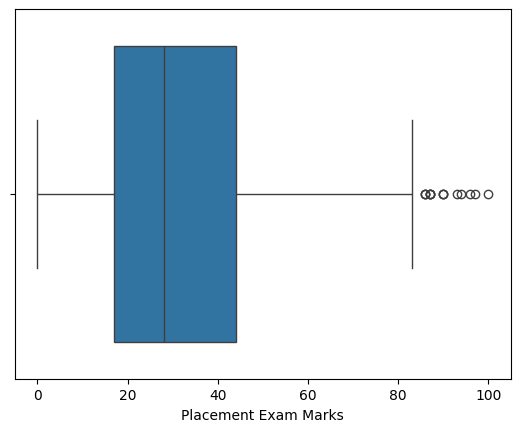

In [6]:
# Box Plot
sns.boxplot(x=df['placement_exam_marks'])
plt.xlabel('Placement Exam Marks')
plt.show()

# As the data is Right Skewed, Most of the values are in the upper half of the distribution.

In [7]:
# Finding The IQR
Q1 = df['placement_exam_marks'].quantile(0.25)
Q3 = df['placement_exam_marks'].quantile(0.75)
IQR = Q3 - Q1

print(f"25th Percentile(Q1): {Q1}")
print(f"75th Percentile(Q3): {Q3}")
print(f"IQR: {IQR}")

25th Percentile(Q1): 17.0
75th Percentile(Q3): 44.0
IQR: 27.0


In [8]:
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR
print(f"Upper Limit: {upper_limit}")
print(f"Lower Limit: {lower_limit}") # As lower marks is zero we don't need to worry about lower_limit at all.

Upper Limit: 84.5
Lower Limit: -23.5


In [9]:
## Finding Outliers:
upper_outlier = df[df['placement_exam_marks'] > upper_limit]
lower_outlier = df[df['placement_exam_marks'] < lower_limit]

print(f"Upper Outliers: {upper_outlier}")
print(f"Lower Outliers: {lower_outlier}") # As lower marks is zero we don't need

Upper Outliers:      cgpa  placement_exam_marks  placed
9    7.75                  94.0       1
40   6.60                  86.0       1
61   7.51                  86.0       0
134  6.33                  93.0       0
162  7.80                  90.0       0
283  7.09                  87.0       0
290  8.38                  87.0       0
311  6.97                  87.0       1
324  6.64                  90.0       0
630  6.56                  96.0       1
685  6.05                  87.0       1
730  6.14                  90.0       1
771  7.31                  86.0       1
846  6.99                  97.0       0
917  5.95                 100.0       0
Lower Outliers: Empty DataFrame
Columns: [cgpa, placement_exam_marks, placed]
Index: []


## 2. Outlier Handling 

### 2.1 Trimming

In [13]:
outliers = pd.concat([upper_outlier, lower_outlier])
print(f"Number of Outliers : {len(outliers)}")
outliers

Number of Outliers : 15


,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [ ]:
new_df = df.drop(outliers.index)
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


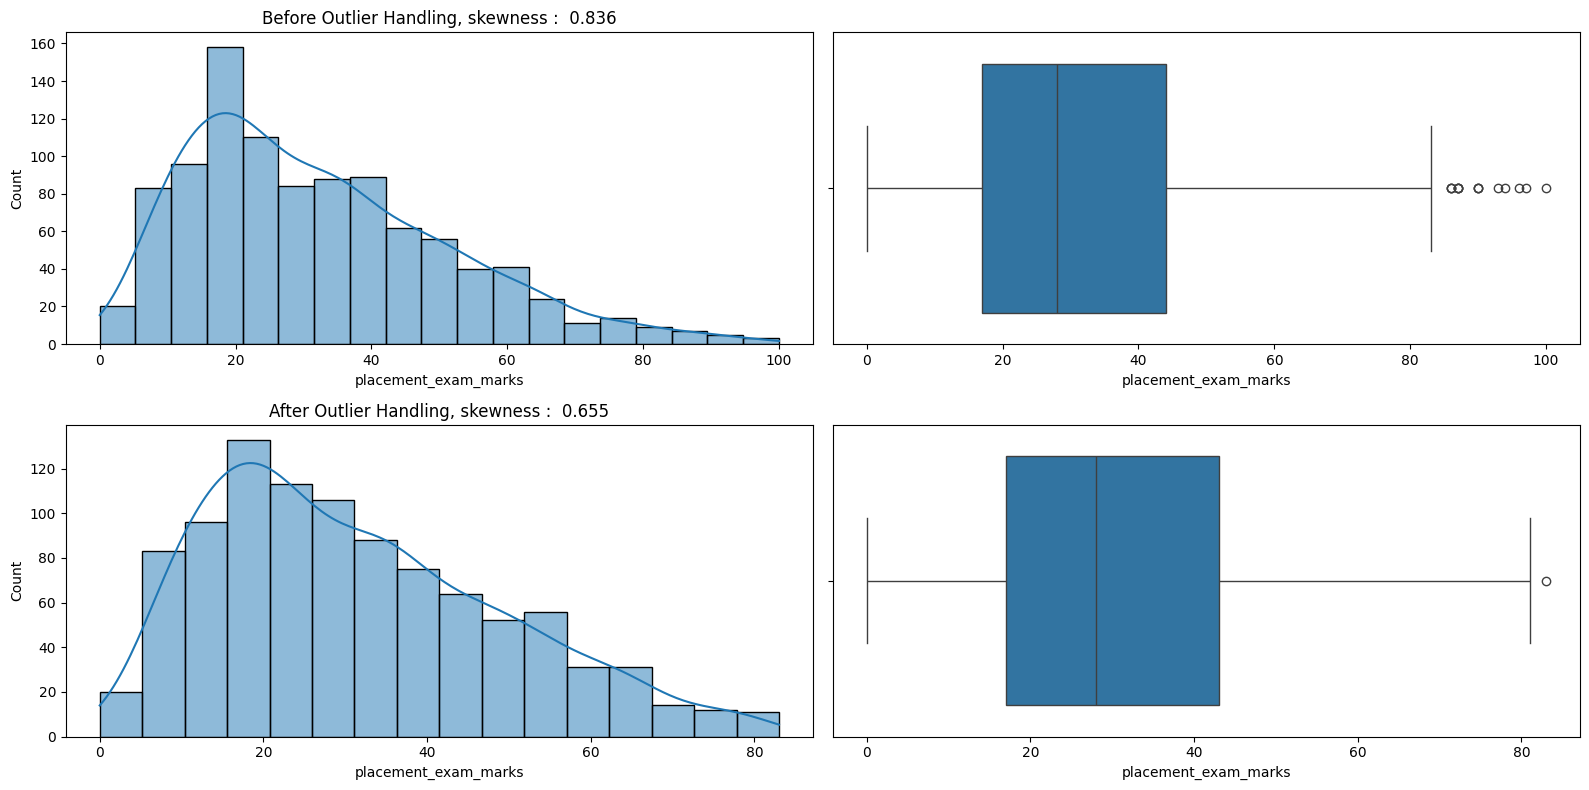

In [ ]:
# Box Plot Before and After Outlier Handling
def box_plot(df, new_df, feature):
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))

    # Before Outlier Handling
    sns.histplot(df[feature], kde=True, ax=axes[0, 0])
    sns.boxplot(x=df[feature], ax=axes[0, 1])
    axes[0,0].set_title(f'Before Outlier Handling, skewness :  {df[feature].skew():.3f}')

    # After Outlier Handling
    sns.histplot(new_df[feature], kde=True, ax=axes[1, 0])
    sns.boxplot(x=new_df[feature], ax=axes[1, 1])
    axes[1,0].set_title(f'After Outlier Handling, skewness :  {new_df[feature].skew():.3f}')

    plt.tight_layout()
    plt.show()



box_plot(df, new_df, 'placement_exam_marks') # Before and After Outlier Handling


### 2.2 Capping

In [24]:
new_df_cap = df.copy()

# Cap the values to be within a certain range
new_df_cap['placement_exam_marks'] = np.where(new_df_cap['placement_exam_marks'] > upper_limit, upper_limit,
                                              np.where(new_df_cap['placement_exam_marks'] < lower_limit, lower_limit, new_df_cap['placement_exam_marks']))

Shape of the DataFrame after Capping: (1000, 3)


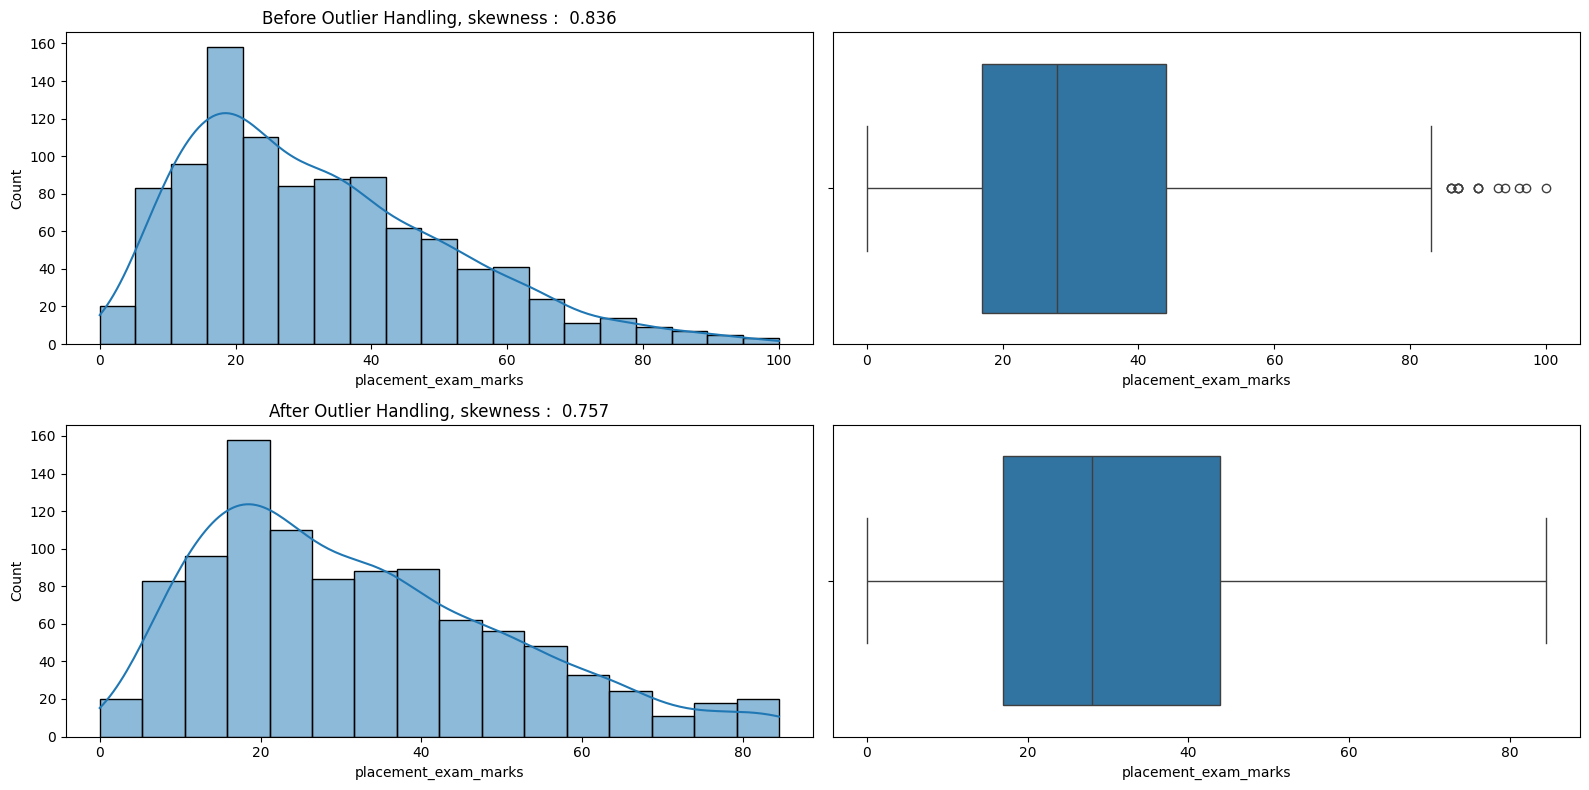

In [26]:
print(f'Shape of the DataFrame after Capping: {new_df_cap.shape}') # The shape remains the same as before because we are only replacing the values that exceed or fall below the limits 
box_plot(df, new_df_cap, 'placement_exam_marks') # Before and After Outlier Handling